In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

In [ ]:
import torch
x = torch.tensor([1,2,3])
print(x.numpy())

# final IF thesis 2 

Dataset shape: (2540047, 49)
Normal train samples: 1553134
Attack test samples: 96385
Model trained.

Sample train scores: [0.09255714 0.13662226 0.14522125 0.13318333 0.14263414 0.1456025
 0.14871259 0.11395006 0.13607922 0.13297977]
μ: 0.1269695853893312
σ: 0.027299883797645343


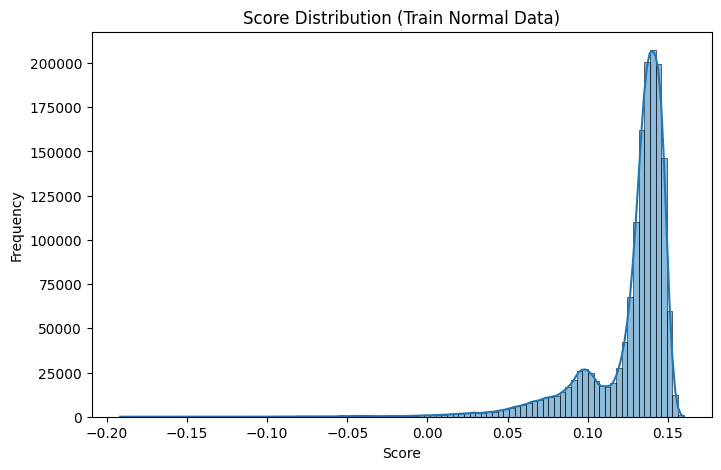


k: 1.7
Threshold: 0.08055978293333413


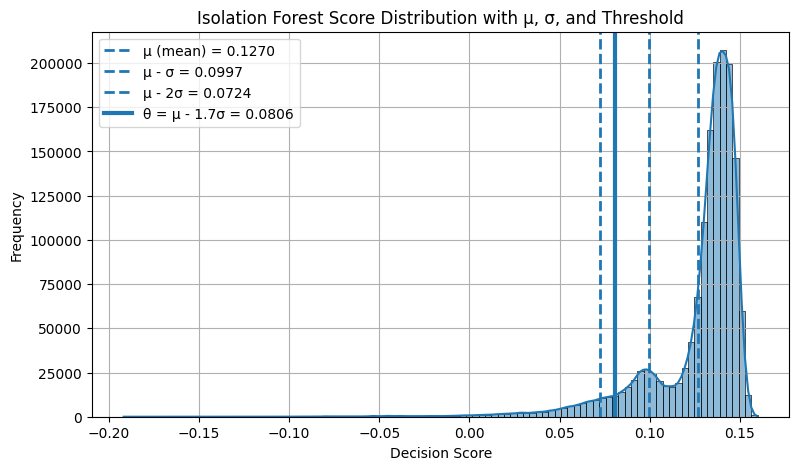


Accuracy: 0.9344527338700682
F1-score: 0.7892204854663921

Classification Report:
              precision    recall  f1-score   support

           0     0.9954    0.9293    0.9612    665630
           1     0.6652    0.9702    0.7892     96385

    accuracy                         0.9345    762015
   macro avg     0.8303    0.9497    0.8752    762015
weighted avg     0.9536    0.9345    0.9394    762015



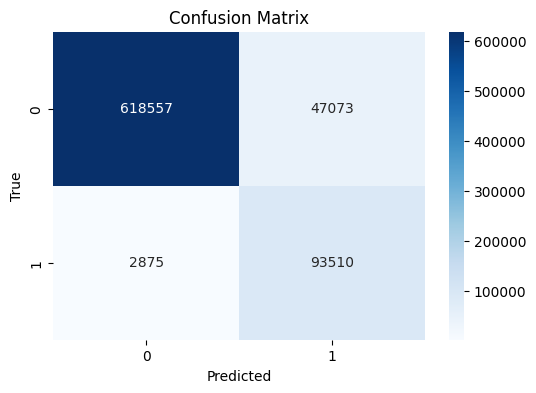


================ ATTACK SCORES =================
Number of attack samples: 96385

First 20 attack scores:
[ 0.00359816  0.04969998  0.00745107  0.01454374  0.05572235 -0.06768391
 -0.00339419  0.04805569 -0.0667453   0.0127166   0.00416819 -0.00185195
  0.04241452 -0.05052672  0.00445395  0.06345384  0.04039328  0.03052415
 -0.03011851  0.01342887]

Attack score statistics:
Min: -0.23518649814109205
Max: 0.1031168573365484
Mean: 0.0035336639725214876
Std: 0.03773272447892902

================ NORMAL SCORES =================
Number of normal samples: 665630

Normal score statistics:
Min: -0.18951501253004477
Max: 0.15987973327360516
Mean: 0.1268442331198595
Std: 0.027485536177929752

================ THRESHOLD ANALYSIS =================
Threshold: 0.08055978293333413
Attacks BELOW threshold (correctly detected): 93510
Attacks ABOVE threshold (missed): 2875
Detection rate: 0.9701717072158531


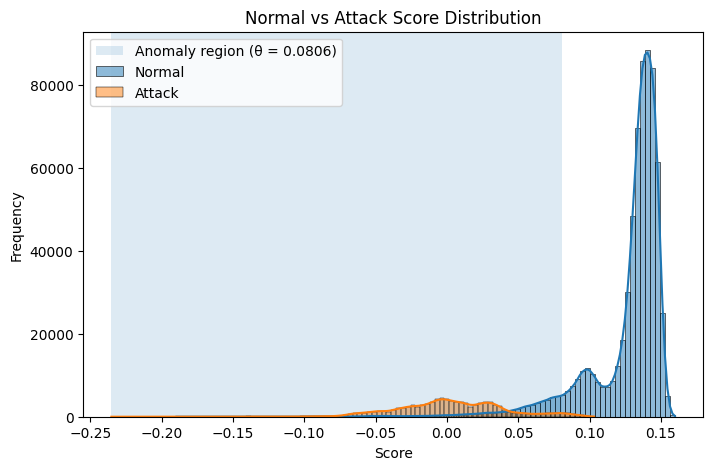

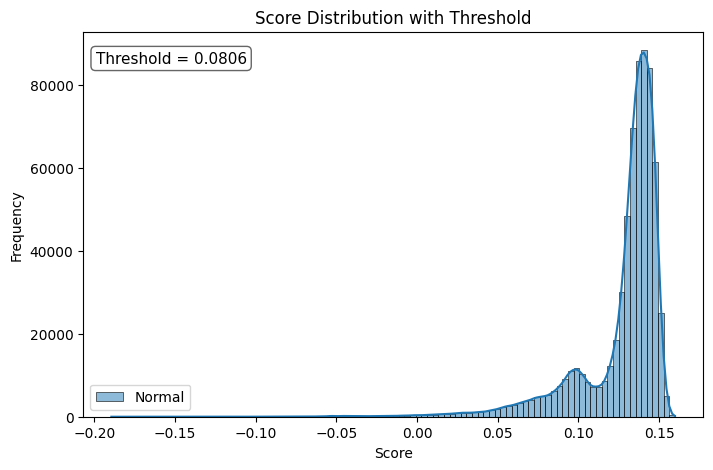

In [1]:
# =========================================================
# 1) Load Dataset
# =========================================================
import os
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_PATH = "/kaggle/input/datasets/mohammedalaaraji/dataset44/"

# Load all parts
dfs = []
for i in range(1, 5):
    file_path = os.path.join(BASE_PATH, f"UNSW-NB15_{i}.csv")
    dfs.append(pd.read_csv(file_path, header=None, low_memory=False))

data = pd.concat(dfs, ignore_index=True)

# Load feature names
features_path = os.path.join(BASE_PATH, "NUSW-NB15_features.csv")
df_col = pd.read_csv(features_path, encoding='ISO-8859-1')

# Clean feature names
df_col['Name'] = df_col['Name'].apply(lambda x: x.strip().replace(' ', '').lower())
data.columns = df_col['Name']

df = data.copy()

print("Dataset shape:", df.shape)


# 1.1) CLEANING / FEATURE FIXES (ADD HERE)
# =========================================================

# Replace '-' in service
if 'service' in df.columns:
    df['service'] = df['service'].replace('-', 'unknown')

# Fix ct_ftp_cmd column
if 'ct_ftp_cmd' in df.columns:
    df['ct_ftp_cmd'] = df['ct_ftp_cmd'].astype(str).str.strip()
    df['ct_ftp_cmd'] = df['ct_ftp_cmd'].replace('', np.nan)
    df['ct_ftp_cmd'] = pd.to_numeric(df['ct_ftp_cmd'], errors='coerce')
    
# =========================================================
# 2) Features and Labels  (SAME STYLE AS X-IIoTID)
# =========================================================

TARGET_LABEL = "label"   # already 0 (normal) / 1 (attack)

# Drop unnecessary columns (same as your note)
df.drop([ 'ltime' , 'attack_cat'], axis=1, inplace=True, errors='ignore')

# Split features / target
X = df.drop(columns=[TARGET_LABEL], errors="ignore")
y_raw = df[TARGET_LABEL]

# Ensure binary (already 0/1 but keep consistent)
y_raw = y_raw.apply(lambda x: 0 if x == 0 else 1)

# =========================================================
# 3) (empty like your structure)
# =========================================================


# =========================================================
# 4) Train/Test Split (SAME LOGIC)
# =========================================================
X_train_full, X_test = train_test_split(
    X,
    test_size=0.3,
    random_state=42,
    stratify=y_raw
)

y_test = y_raw.loc[X_test.index].values

# Train ONLY on normal
X_train = X_train_full[y_raw.loc[X_train_full.index] == 0].copy()

print("Normal train samples:", len(X_train))
print("Attack test samples:", sum(y_test == 1))



# =========================================================
# 3B) Preprocessing (NO LEAKAGE)
# =========================================================
X_train = X_train.copy()
X_test = X_test.copy()

encoders = {}
num_medians = {}

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        # fill missing using TRAIN
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)

        # fit encoder on TRAIN only
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))

        # -------- FIXED PART --------
        X_test[col] = X_test[col].astype(str)

        # mapping from train
        mapping = {cls: idx for idx, cls in enumerate(le.classes_)}

        # next label for unseen
        next_label = len(le.classes_)

        # encode test with unseen handling
        X_test[col] = X_test[col].map(
            lambda x: mapping[x] if x in mapping else next_label
        )
        # --------------------------------

        encoders[col] = le

    else:
        # numeric columns
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

        num_medians[col] = median_val
# =========================================================
# 5) Scaling
# =========================================================
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# =========================================================
# 6) Train Isolation Forest (FIXED CONFIG)
# =========================================================
model = IsolationForest(
    n_estimators=100,
    max_samples=1.0,
    contamination="auto",
    max_features=0.5,
    bootstrap=True,
    random_state=42    # run = 2
)

model.fit(X_train_s)
print("Model trained.")

# =========================================================
# 7) Compute Scores
# =========================================================
scores_train = model.decision_function(X_train_s)

mu = np.mean(scores_train)
sigma = np.std(scores_train)

print("\nSample train scores:", scores_train[:10])
print("μ:", mu)
print("σ:", sigma)

# =========================================================
# 8) Distribution Plot
# =========================================================
plt.figure(figsize=(8,5))
sns.histplot(scores_train, bins=100, kde=True)

plt.title("Score Distribution (Train Normal Data)")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 9) Threshold (FIXED k)
# =========================================================
k = 1.7
threshold = mu - k * sigma

print("\nk:", k)
print("Threshold:", threshold)

# =========================================================
# =========================================================
# 10) Plot Distribution with μ, σ, and Threshold
# =========================================================
plt.figure(figsize=(9,5))

sns.histplot(scores_train, bins=100, kde=True)

# Mean
plt.axvline(mu, linestyle='--', linewidth=2, label=f"μ (mean) = {mu:.4f}")

# One standard deviation
plt.axvline(mu - sigma, linestyle='--', linewidth=2, label=f"μ - σ = {(mu - sigma):.4f}")

# Two standard deviations (optional but useful)
plt.axvline(mu - 2*sigma, linestyle='--', linewidth=2, label=f"μ - 2σ = {(mu - 2*sigma):.4f}")

# Threshold
plt.axvline(threshold, linestyle='-', linewidth=3, label=f"θ = μ - {k}σ = {threshold:.4f}")

plt.title("Isolation Forest Score Distribution with μ, σ, and Threshold")
plt.xlabel("Decision Score")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()
# =========================================================
# 11) Prediction
# =========================================================
scores_test = model.decision_function(X_test_s)
y_pred = np.where(scores_test < threshold, 1, 0)

# =========================================================
# 12) Evaluation
# =========================================================
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy:", acc)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# =========================================================
# 13) Confusion Matrix
# =========================================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()
# =========================================================
# 14) Attack Scores Analysis
# =========================================================

# Separate scores
attack_scores = scores_test[y_test == 1]
normal_scores = scores_test[y_test == 0]

print("\n================ ATTACK SCORES =================")
print("Number of attack samples:", len(attack_scores))

# Avoid crash if no attacks
if len(attack_scores) > 0:
    print("\nFirst 20 attack scores:")
    print(attack_scores[:20])

    print("\nAttack score statistics:")
    print("Min:", np.min(attack_scores))
    print("Max:", np.max(attack_scores))
    print("Mean:", np.mean(attack_scores))
    print("Std:", np.std(attack_scores))
else:
    print("No attack samples found in test set.")

print("\n================ NORMAL SCORES =================")
print("Number of normal samples:", len(normal_scores))

if len(normal_scores) > 0:
    print("\nNormal score statistics:")
    print("Min:", np.min(normal_scores))
    print("Max:", np.max(normal_scores))
    print("Mean:", np.mean(normal_scores))
    print("Std:", np.std(normal_scores))

# =========================================================
# Threshold analysis
# =========================================================
print("\n================ THRESHOLD ANALYSIS =================")
print("Threshold:", threshold)

if len(attack_scores) > 0:
    below_threshold = np.sum(attack_scores < threshold)
    above_threshold = np.sum(attack_scores >= threshold)

    print("Attacks BELOW threshold (correctly detected):", below_threshold)
    print("Attacks ABOVE threshold (missed):", above_threshold)

    print("Detection rate:", below_threshold / len(attack_scores))

# =========================================================
# 14B) Plot Attack vs Normal Scores
# =========================================================
plt.figure(figsize=(8,5))

if len(normal_scores) > 0:
    sns.histplot(normal_scores, bins=100, kde=True, label="Normal")

if len(attack_scores) > 0:
    sns.histplot(attack_scores, bins=100, kde=True, label="Attack")

# Threshold line
# Highlight anomaly region ONLY (no line)
plt.axvspan(
    min(scores_test),
    threshold,
    alpha=0.15,
    label=f"Anomaly region (θ = {threshold:.4f})"
)

plt.legend()
plt.title("Normal vs Attack Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.show()




plt.figure(figsize=(8,5))

# Only normal distribution
sns.histplot(normal_scores, bins=100, kde=True, label="Normal")
#plt.figure(figsize=(8,5))
#sns.histplot(scores_train, bins=100, kde=True)

# Add threshold text (top-left inside plot)
plt.text(
    0.02, 0.95,                      # position (left, top)
    f"Threshold = {threshold:.4f}",  # text
    transform=plt.gca().transAxes,  # use axis coordinates
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.6)
)

plt.title("Score Distribution with Threshold")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()